# Global background esimtation

`opticam` uses `photutils` to handle two-dimensional image backgrounds. In this notebook, I will demonstrate how to define backgrounds for use with `opticam`, as well as explain `opticam`'s default behaviour when no background is specified.

## Test Image

First thing's first, let's create and open an image so we can compute its background:

In [1]:
from pathlib import Path

import opticam

out_dir = Path('out')

opticam.generate_observations(
    out_directory=out_dir / 'data',
    n_images=5,
    circular_aperture=False,
    )

[OPTICAM] variable source is at (131, 115)
[OPTICAM] variability RMS: 0.02 %
[OPTICAM] variability frequency: 0.135 Hz
[OPTICAM] variability phase lags:
    [OPTICAM] g-band: 0.000 radians
    [OPTICAM] r-band: 1.571 radians
    [OPTICAM] i-band: 3.142 radians


Generating observations:   0%|                                                                                                                                                                                                                                        |[00:00<?]

Generating observations:  20%|█████████████████████████████████████████████▌                                                                                                                                                                                      |[00:00<00:01]

Generating observations:  40%|███████████████████████████████████████████████████████████████████████████████████████████▏                                                                                                                                        |[00:00<00:01]

Generating observations:  60%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                                           |[00:01<00:00]

Generating observations:  80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                             |[00:01<00:00]

Generating observations: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:01<00:00]

Generating observations: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:01<00:00]

In [2]:
from astropy.io import fits
import numpy as np
import os

files = os.listdir(out_dir / 'data')

with fits.open(out_dir / 'data' / files[0]) as hdul:
    print(repr(hdul[0].header))
    image = np.array(hdul[0].data)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
FILTER  = 'i       '                                                            
BINNING = '4x4     '                                                            
GAIN    =                  1.0                                                  
EXPOSURE=                  1.0                                                  
DARKCURR=                  0.0                                                  
RA      =                  0.0                                                  
DEC     =                  0

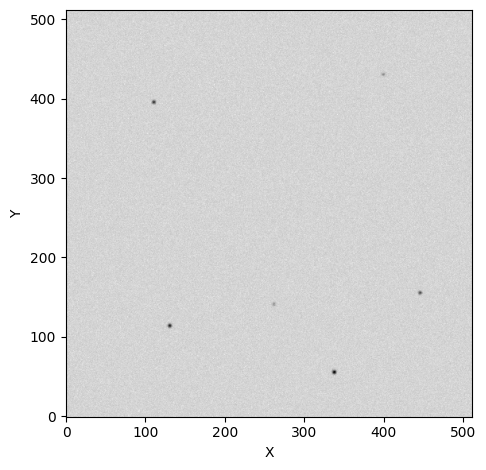

In [3]:
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt

fig, ax = plt.subplots(tight_layout=True)

im = ax.imshow(
    image,
    norm=simple_norm(image, stretch="sqrt"),
    origin="lower",
    cmap="Greys",
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

## Default Background

`opticam`'s default background estimator is the default `Background2D()` estimator from `photutils` with some added convenience tailored to OPTICAM. Let's look at the background image produced by the default estimator:

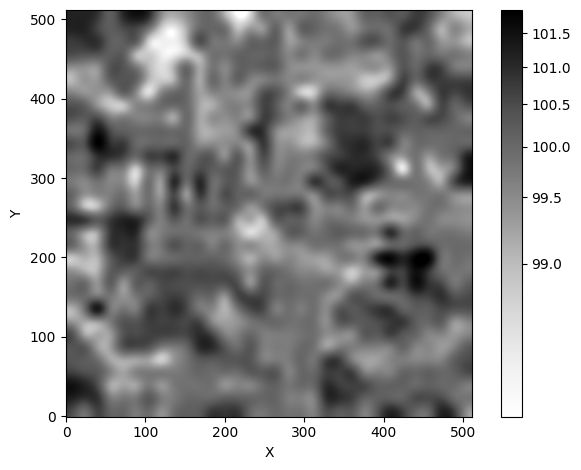

In [4]:
default_background = opticam.DefaultBackground(
    box_size=image.shape[0] // 32,  # opticam sets this parameter to image.shape[0] // 32 by default
    )

bkg = default_background(image)  # compute the background
bkg_image = bkg.background  # get the background image

fig, ax = plt.subplots(tight_layout=True)

im = ax.imshow(
    bkg_image,
    norm=simple_norm(bkg_image, stretch="sqrt"),
    origin="lower",
    cmap="Greys",
    )

fig.colorbar(im)

ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

As we can see, the background is around 100 counts, which is the expected value. We can also look at the background mesh to see if any regions of the image have been excluded by the background estimator:

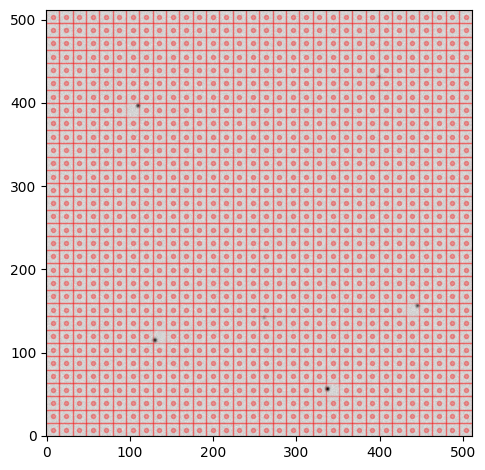

In [5]:
fig, ax = plt.subplots(tight_layout=True)

im = ax.imshow(
    image,
    norm=simple_norm(image, stretch="sqrt"),
    origin="lower",
    cmap="Greys",
    )
bkg.plot_meshes(
    outlines=True,
    marker='.',
    color='r',
    alpha=0.3,
    ax=ax,
    )

plt.show()

The default size of the background "pixels" for `opticam.DefaultBackground` is the width of the image divided by 16. This value is generally good across a range of observing conditions, but it can, of course, be changed on a case-by-case basis. The `photutils` documentation suggests setting the `box_size` (i.e., background "pixel" size) to a value which is small, but larger than the typical source size. For these simulated data, we could probably get away with a smaller `box_size`, but such fine-tunings are left to the user.

Let's subtract the background and compare the histograms of pixel values before and after removing the background from the image:

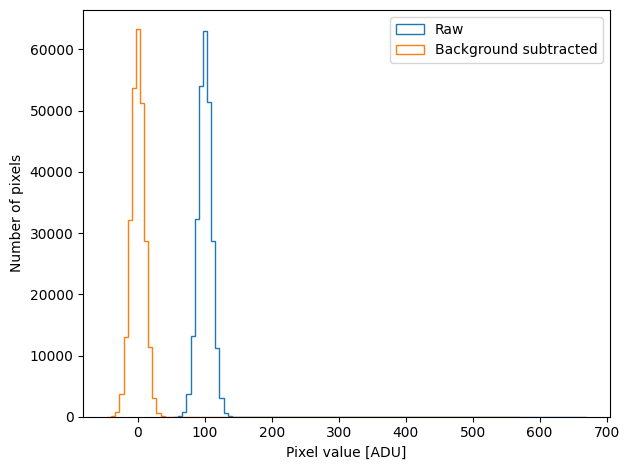

In [6]:
fig, ax = plt.subplots(tight_layout=True)

ax.hist(
    image.flatten(),
    bins=100,
    histtype="step",
    label="Raw",
    )

ax.hist(
    (image - bkg_image).flatten(),
    bins=100,
    histtype="step",
    label="Background subtracted",
    )

ax.set_xlabel("Pixel value [ADU]")
ax.set_ylabel("Number of pixels")

ax.legend()

plt.show()

We can see that the background has been massively reduced. After subtracting the background, the pixel values appear approximately Gaussian distributed about zero.

Using `opticam`'s default background should be "good enough" most of the time. However, in some cases, we may see better results if we implement a custom background estimator.

## Custom Backgrounds

Let's now define a custom background estimator. Custom background estimators must be `callable`s that take an image (`numpy` `NDArray`) as input and return a `photutils.background.Background2D` instance:

In [7]:
from photutils.background import Background2D, BiweightLocationBackground, BiweightScaleBackgroundRMS

class CustomBackground:
    
    def __init__(
        self,
        box_size,
        bkg_estimator=BiweightLocationBackground(),
        bkgrms_estimator=BiweightScaleBackgroundRMS(),
        ):
        
        self.box_size = box_size
        self.bkg_estimator=bkg_estimator
        self.bkgrms_estimator=bkgrms_estimator
    
    def __call__(
        self,
        image,
        ):
        
        return Background2D(
            image,
            self.box_size,
            bkg_estimator=self.bkg_estimator,
            bkgrms_estimator=self.bkgrms_estimator,
            )

In this example, I have defined `CustomBackground` as a class that requires a `box_size` parameter, just like `opticam.DefaultBackground`. Unlike `opticam.DefaultBackground`, however, `CustomBackground` takes the background and background RMS estimators as additional arguments. By default, `CustomBackground` uses the `photutils.background.BiweightLocationBackground` background estimator and `photutils.background.BiweightScaleBackgroundRMS` background RMS estimator, while `opticam.DefaultBackground` is limited to the `photutils.background.SExtractorBackground` and `photutils.background.StdBackgroundRMS` estimators. Of course, custom background and background RMS estimators can also be defined, though this is more advanced (see https://photutils.readthedocs.io/en/stable/user_guide/background.html#d-background-and-noise-estimation for more details).

We could have equally defined a custom background estimator using a function instead of a class, which is much simpler:

In [8]:
%%writefile custom_routines.py
from photutils.background import Background2D, BiweightLocationBackground, BiweightScaleBackgroundRMS


def custom_background(
    image,
    box_size,
    ):
    
    return Background2D(
            image,
            box_size,
            bkg_estimator=BiweightLocationBackground(),
            bkgrms_estimator=BiweightScaleBackgroundRMS(),
            )

Writing custom_routines.py


Due to compatibility issues, routines defined inside of IPython notebooks cannot be used by `multiprocessing` (used by `opticam`). To overcome this issue, we have used the `%%writefile` magic command to write our `custom_background()` function to a temporary module called `custom_routines.py`, such that it can be imported by `multiprocessing`. This is required in Python $\geq$ 3.14.

Let's now compare `CustomBackground` to `opticam.DefaultBackground`:

In [9]:
from functools import partial

from custom_routines import custom_background

# class:
custom_background_class = CustomBackground(box_size=image.shape[0] // 32)

# or, for our function, we want to fix the box_size parameter using functools.partial:
custom_background_func = partial(
    custom_background,
    box_size=image.shape[0] // 32,  # set box size to image width / 32, similarly to opticam's default behaviour
    )

custom_bkg_class_image = custom_background_class(image).background
custom_bkg_func_image = custom_background_func(image).background

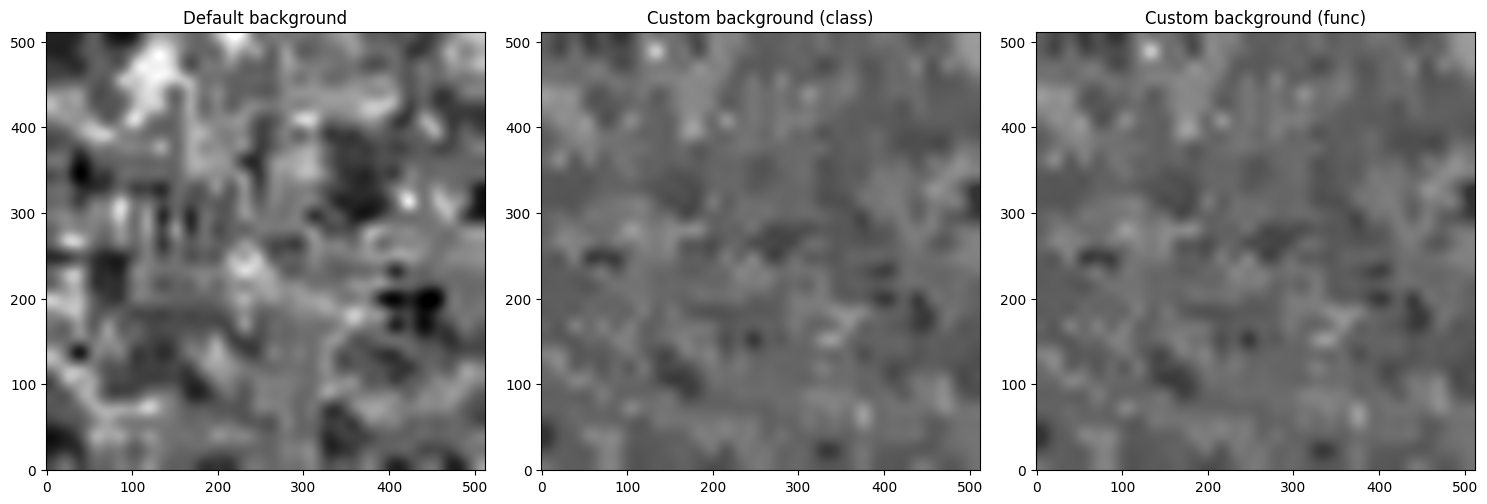

In [10]:
fig, ax = plt.subplots(
    ncols=3,
    tight_layout=True,
    figsize=(15, 5),
    )

im = ax[0].imshow(
    bkg_image,
    norm=simple_norm(bkg_image, stretch="sqrt"),
    origin="lower",
    cmap="Greys",
    )
ax[0].set_title("Default background")

im = ax[1].imshow(
    custom_bkg_class_image,
    norm=simple_norm(bkg_image, stretch="sqrt"),
    origin="lower",
    cmap="Greys",
    )
ax[1].set_title("Custom background (class)")

im = ax[2].imshow(
    custom_bkg_func_image,
    norm=simple_norm(bkg_image, stretch="sqrt"),
    origin="lower",
    cmap="Greys",
    )
ax[2].set_title("Custom background (func)")

plt.show()

As we can see, the default background and our custom backgrounds are subtly different (note that they also share the same normalisation). Let's compare the histograms between these background estimators to better quantify the differences:

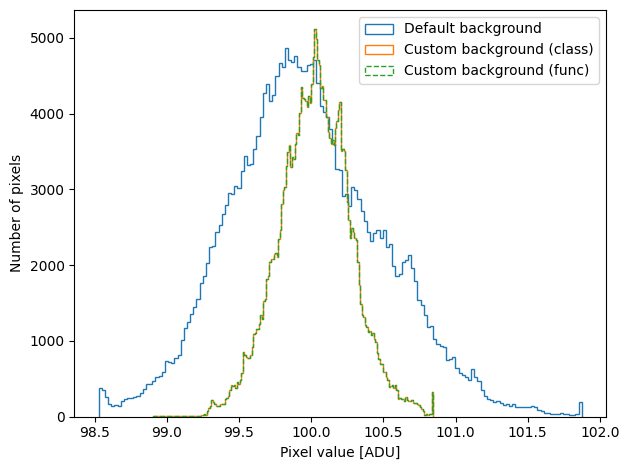

In [11]:
fig, ax = plt.subplots(tight_layout=True)

ax.hist(
    bkg_image.flatten(),
    bins='auto',
    histtype="step",
    label="Default background",
    )
ax.hist(
    custom_bkg_class_image.flatten(),
    bins='auto',
    histtype="step",
    label="Custom background (class)",
    )
ax.hist(
    custom_bkg_func_image.flatten(),
    bins='auto',
    histtype="step",
    label="Custom background (func)",
    ls='--',
    )

ax.set_xlabel("Pixel value [ADU]")
ax.set_ylabel("Number of pixels")

ax.legend()

plt.show()

Now we can see that the default estimator is very different to our custom estimators, while both our class-based and function-based background estimators are, of course, identical.

Let's see how to pass our custom background estimators to `opticam.Reducer`:

[OPTICAM] out/reduced/custom_background_function not found, attempting to create ...
[OPTICAM] out/reduced/custom_background_function created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory:  53%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                                     |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Checking instrument OPTICAM_MX.
[OPTICAM] OPTICAM_MX sucessfully passed all checks.


...

[OPTICAM] Filters: g, r, i


[OPTICAM] 5 g images.


[OPTICAM] 5 r images.


[OPTICAM] 5 i images.


[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.


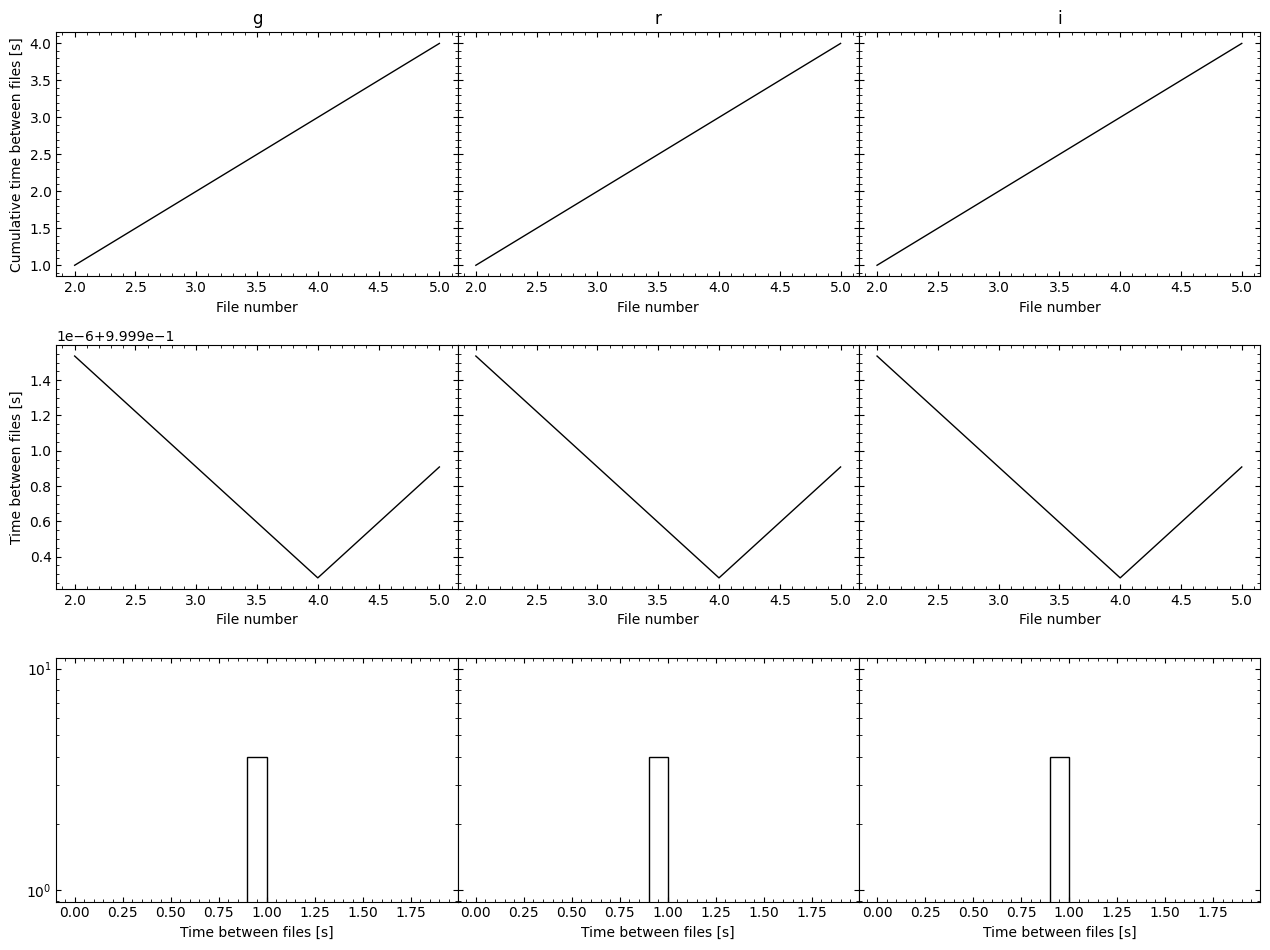

[OPTICAM] Creating source catalogs.


[OPTICAM] Aligning g images:   0%|                                                                                                                                                                                                                                    |[00:00<?]

[OPTICAM] Aligning g images:  20%|████████████████████████████████████████████▊                                                                                                                                                                                   |[00:03<00:14]

[OPTICAM] Aligning g images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:03<00:00]

[OPTICAM] [OPTICAM] Done.


...

[OPTICAM] Aligning i images:  20%|████████████████████████████████████████████▊                                                                                                                                                                                   |[00:03<00:14]

[OPTICAM] Aligning i images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:03<00:00]

[OPTICAM] [OPTICAM] Done.


[OPTICAM] [OPTICAM] 5 image(s) aligned.


[OPTICAM] [OPTICAM] 0 image(s) could not be aligned.


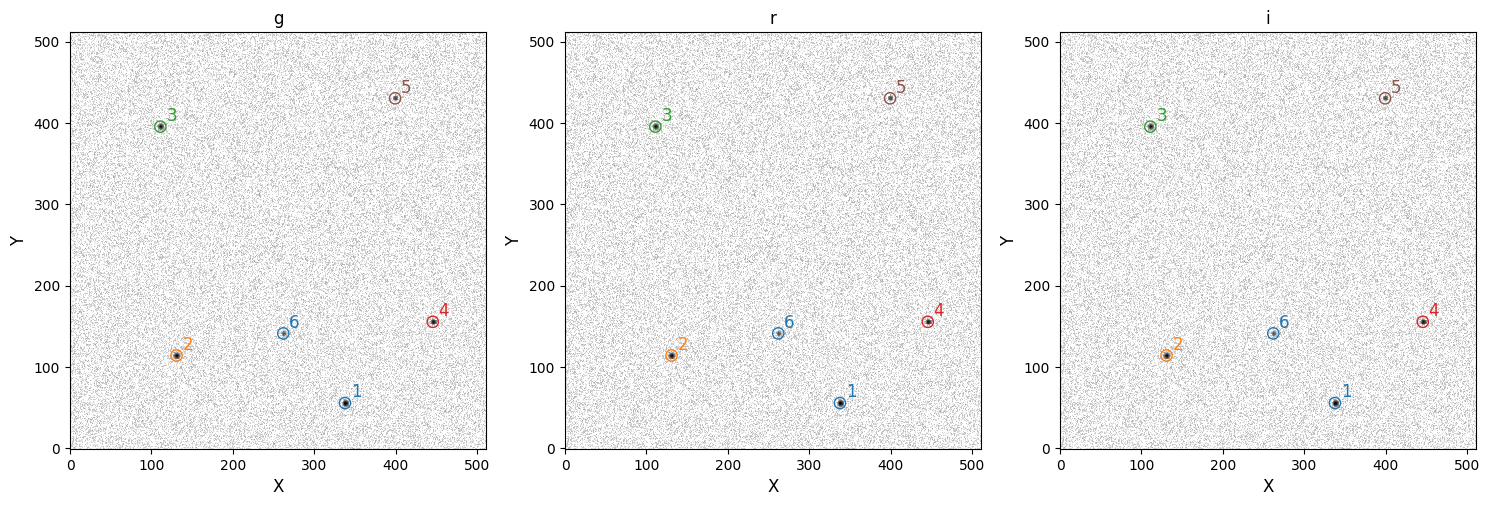

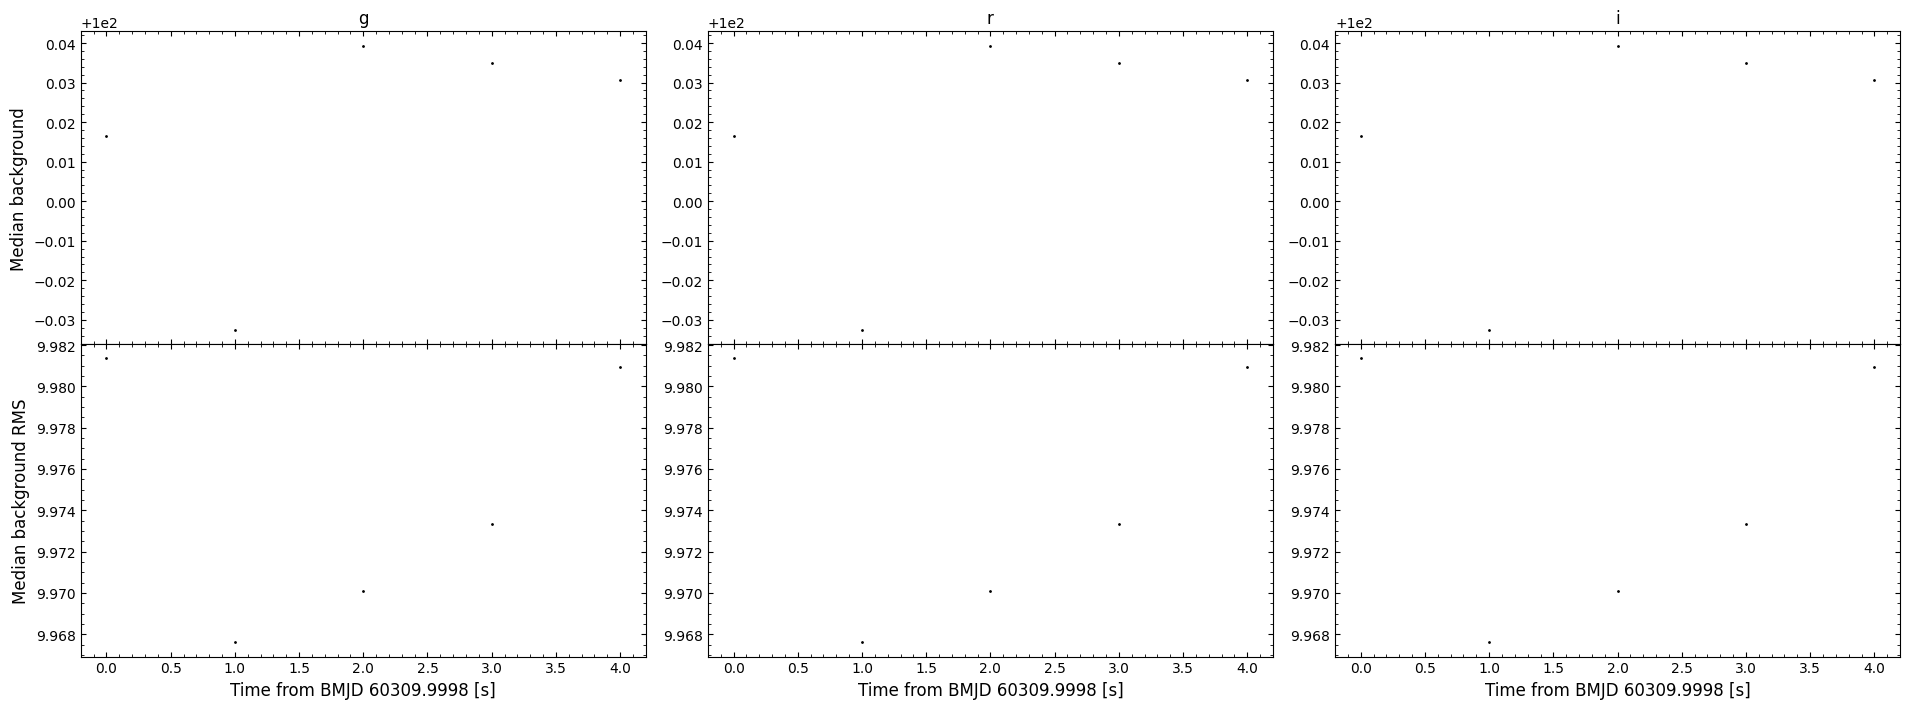

In [12]:
reducer = opticam.Reducer(
    out_directory=out_dir / 'reduced' / 'custom_background_function',
    data_directory=out_dir / 'data',
    background=custom_background_func,  # pass custom background estimator
    remove_cosmic_rays=True,
)

reducer.create_catalogs()

As we can see, our custom background estimator infers an average background of $\sim 100$ counts with an RMS of $\sim 10$, both of which are the expected values. We could have equally used our class-based background estimator, similar to the implementation of the default background estimator, instead of the function-based one.

Let's check how this compares to `opticam`'s default background estimator:

[OPTICAM] out/reduced/default_background not found, attempting to create ...
[OPTICAM] out/reduced/default_background created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory:  53%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                                     |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Checking instrument OPTICAM_MX.
[OPTICAM] OPTICAM_MX sucessfully passed all checks.


...

[OPTICAM] Filters: g, r, i


[OPTICAM] 5 g images.


[OPTICAM] 5 r images.


[OPTICAM] 5 i images.


[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.


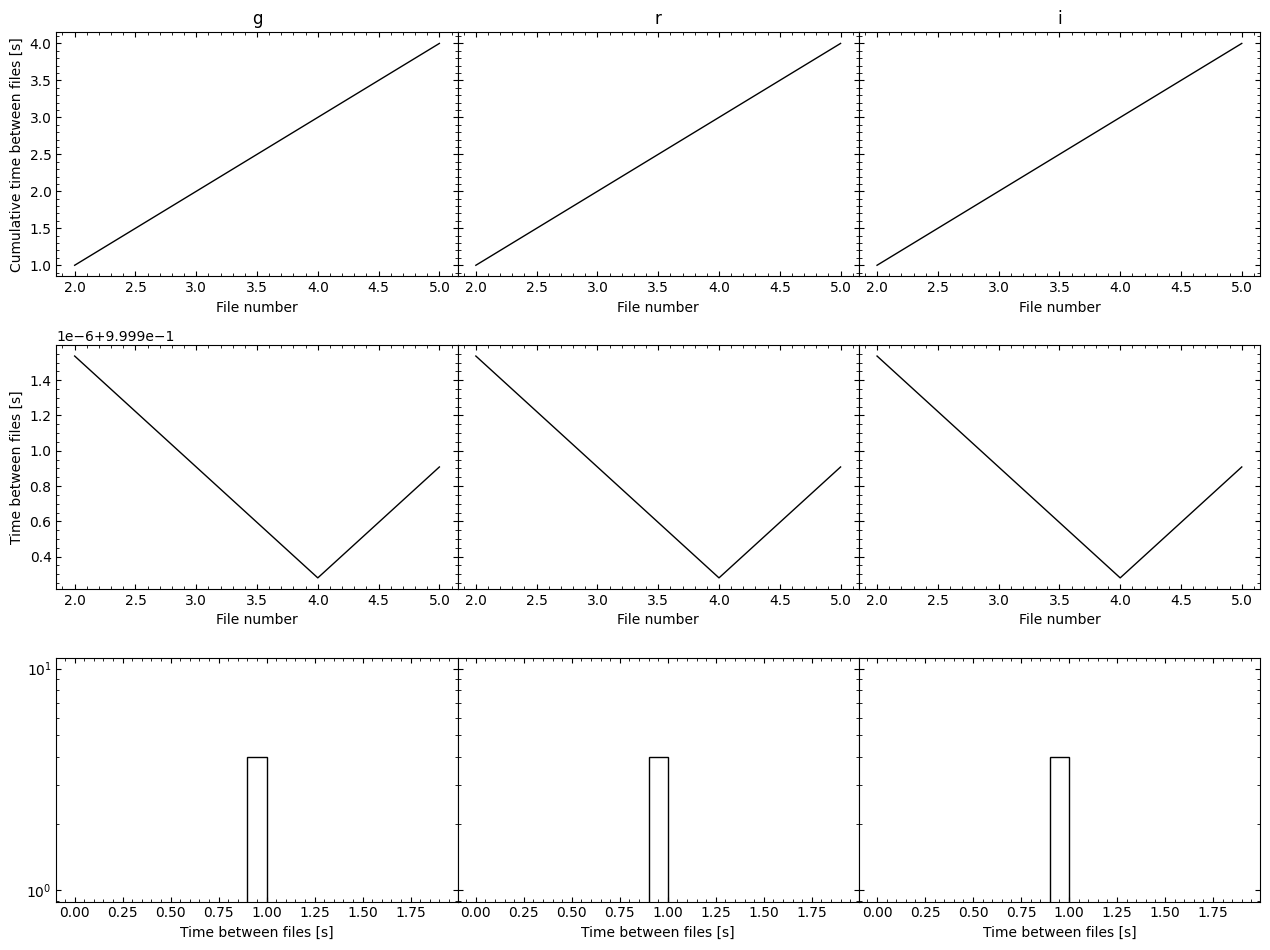

[OPTICAM] Creating source catalogs.


[OPTICAM] Aligning g images:   0%|                                                                                                                                                                                                                                    |[00:00<?]

[OPTICAM] Aligning g images:  20%|████████████████████████████████████████████▊                                                                                                                                                                                   |[00:04<00:16]

[OPTICAM] Aligning g images:  40%|█████████████████████████████████████████████████████████████████████████████████████████▌                                                                                                                                      |[00:04<00:05]

[OPTICAM] Aligning g images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:04<00:00]

...

[OPTICAM] Aligning i images:  20%|████████████████████████████████████████████▊                                                                                                                                                                                   |[00:04<00:19]

[OPTICAM] Aligning i images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:04<00:00]

[OPTICAM] [OPTICAM] Done.


[OPTICAM] [OPTICAM] 5 image(s) aligned.


[OPTICAM] [OPTICAM] 0 image(s) could not be aligned.


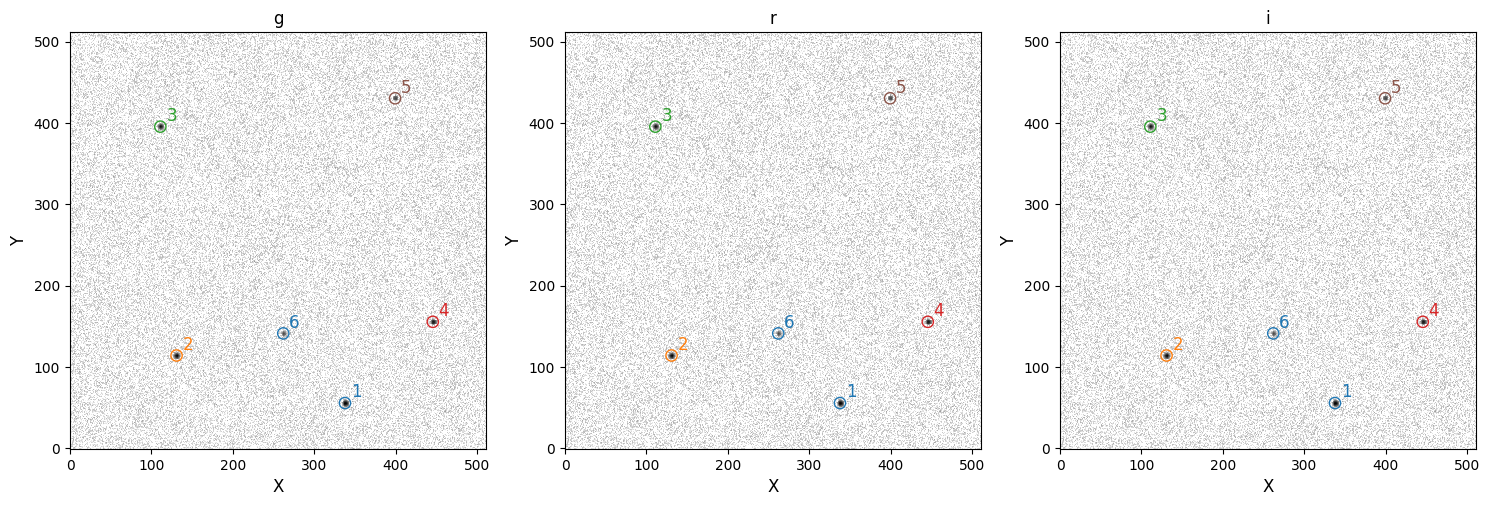

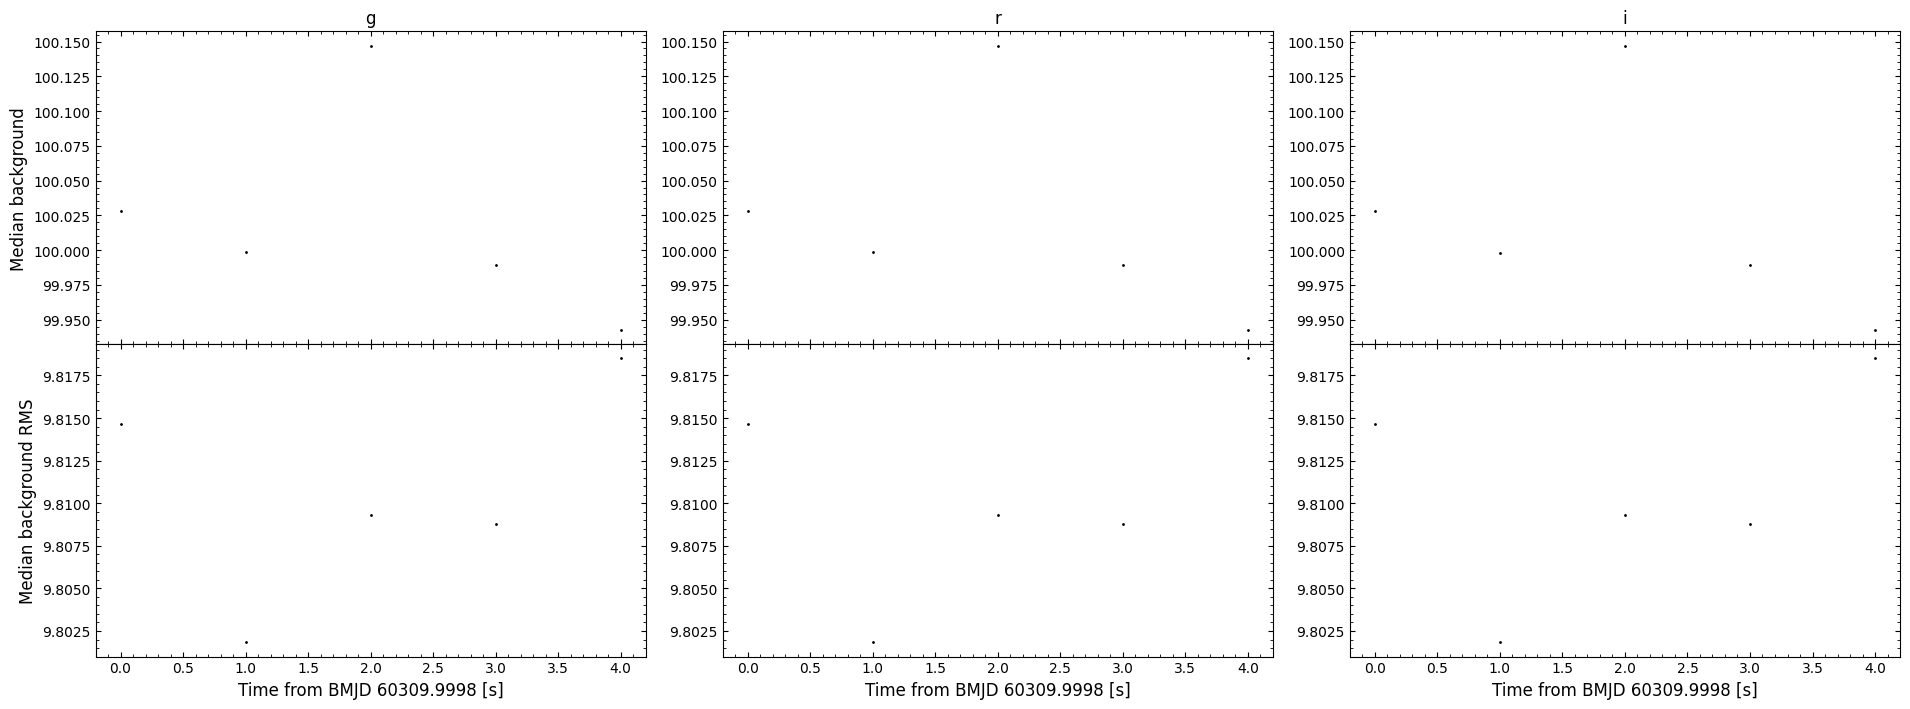

In [13]:
reducer = opticam.Reducer(
    out_directory=out_dir / 'reduced' / 'default_background',
    data_directory=out_dir / 'data',
    remove_cosmic_rays=True,
)

reducer.create_catalogs()

Unsurprisingly, we again find that the default background estimator infers an average background of $\sim 100$ counts with an RMS of $\sim 10$.

That concludes the backgrounds tutorial for `opticam`! In most cases, `opticam.DefaultBackground` should be "good enough", but we have seen how custom background estimators could be implemented if necessary. For more details on implementing custom background estimators, I refer to the excellent `photutils` documentation: https://photutils.readthedocs.io/en/stable/user_guide/background.html#d-background-and-noise-estimation.